# Bài 2: DeepLabV3 — Atrous Convolution & ASPP

Bạn sẽ dùng ResNet18 pretrained đến hết `layer3` (output stride 16), tự xây dựng ASPP và so sánh với một normal-convolution head. Không sử dụng DeepLabV3 có sẵn.

**Quy trình:** hoàn thành mọi cell `TODO`, chạy notebook từ trên xuống, kiểm tra feature/output shape, train hai model, rồi dùng kết quả thật để hoàn thiện nhận xét cuối bài.


## 1. Setup


In [1]:
!pip install -q torch torchvision matplotlib pandas pillow tqdm

In [2]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

from torchvision.models import ResNet18_Weights, resnet18

In [3]:
# =========================================================
# CẤU HÌNH
# =========================================================
# Chọn nơi lưu dataset theo môi trường chạy:
# - Google Colab  -> lưu trên Google Drive để tránh phải tải lại dataset.
# - Kaggle        -> lưu trong /kaggle/working.
# - Jupyter local -> lưu trong thư mục ./data.

IN_COLAB = "COLAB_RELEASE_TAG" in __import__("os").environ
IN_KAGGLE = Path("/kaggle/working").exists()

if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        DATA_ROOT = "/content/drive/MyDrive/datasets/OxfordIIITPet"
    except (NotImplementedError, RuntimeError):
        print("Không thể mount Google Drive. Dataset sẽ được lưu trong /content/data.")
        DATA_ROOT = "/content/data/OxfordIIITPet"

elif IN_KAGGLE:
    DATA_ROOT = "/kaggle/working/datasets/OxfordIIITPet"

else:
    DATA_ROOT = "./data/OxfordIIITPet"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 3
SEED = 42
NUM_EPOCHS = 10  # Có thể tăng để mô hình học tốt hơn.
LEARNING_RATE = 1e-4
NUM_WORKERS = 0

Mounted at /content/drive


In [4]:
# Cố định seed để kết quả dễ tái lập.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset và preprocessing

Notebook dùng cùng Oxford-IIIT Pet split, ImageNet normalization và cách shift trimap `{1,2,3} → {0,1,2}` như Bài 1.


In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class PetSegmentationDataset(Dataset):
    """Áp dụng cùng phép biến đổi cho ảnh và mask."""

    def __init__(self, subset, image_size):
        self.subset = subset
        self.image_size = image_size

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, mask = self.subset[index]
        image = TF.resize(image, [self.image_size, self.image_size],
                          interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.image_size, self.image_size],
                         interpolation=InterpolationMode.NEAREST)
        image = TF.to_tensor(image)
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)

        # Trimap Oxford-IIIT Pet dùng nhãn {1, 2, 3}.
        # CrossEntropyLoss yêu cầu nhãn lớp bắt đầu từ 0.
        mask = torch.as_tensor(np.array(mask), dtype=torch.long) - 1
        return image, mask


base_dataset = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="segmentation",
    download=True,
)

train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    base_dataset, [train_size, val_size], generator=split_generator
)

train_dataset = PetSegmentationDataset(train_subset, IMAGE_SIZE)
val_dataset = PetSegmentationDataset(val_subset, IMAGE_SIZE)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

sample_mask = train_dataset[0][1]
assert set(sample_mask.unique().tolist()).issubset({0, 1, 2})
print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)}")
print("Shifted mask labels:", sample_mask.unique().tolist())


100%|██████████| 792M/792M [00:32<00:00, 24.1MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 6.81MB/s]


Train: 2944 | Validation: 736
Shifted mask labels: [0, 1, 2]


## 3. Visualization dataset


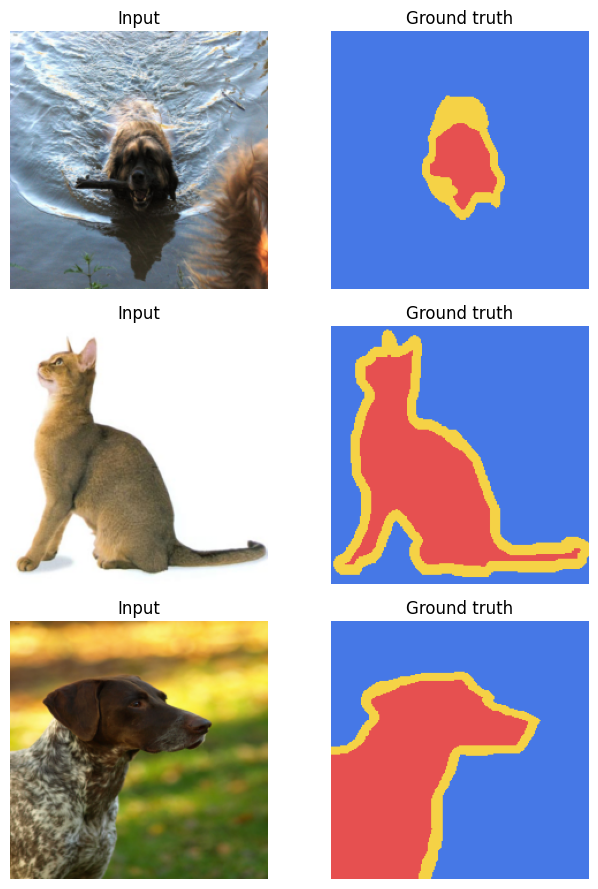

In [6]:
CLASS_NAMES = ["pet", "background", "border"]
MASK_COLORS = np.array([
    [230, 80, 80],
    [70, 120, 230],
    [245, 210, 70],
], dtype=np.uint8)


def denormalize(image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)


def colorize_mask(mask):
    return MASK_COLORS[mask.cpu().numpy()]


def show_dataset_samples(dataset, count=3):
    fig, axes = plt.subplots(count, 2, figsize=(7, 3 * count))
    for row in range(count):
        image, mask = dataset[row]
        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].set_title("Input")
        axes[row, 1].imshow(colorize_mask(mask))
        axes[row, 1].set_title("Ground truth")
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


show_dataset_samples(train_dataset)


## 4. ResNet18 backbone — PROVIDED CODE

Backbone dừng ở `layer3`, bỏ `layer4`, average pool và classifier. Vì vậy output stride là 16; ảnh 224×224 tạo feature map khoảng 14×14 trước ASPP.


In [7]:
def build_resnet18_backbone():
    resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
        resnet.layer1, resnet.layer2, resnet.layer3,
    )
    return backbone


BACKBONE_OUT_CHANNELS = 256

# Kiểm tra: 224 / output stride 16 = 14.
with torch.no_grad():
    backbone_check = build_resnet18_backbone().eval()
    feature_check = backbone_check(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE))
print("Backbone feature shape:", feature_check.shape)
assert feature_check.shape == (2, BACKBONE_OUT_CHANNELS, 14, 14)
del backbone_check, feature_check


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


Backbone feature shape: torch.Size([2, 256, 14, 14])


## 5. Architecture overview

`Input → ResNet18 (đến layer3) → ASPP → 1×1 classifier → bilinear upsample → mask logits`.

ASPP áp dụng nhiều convolution với dilation rate khác nhau trên cùng một feature map. Mỗi nhánh quan sát một receptive field khác nhau, rồi các feature được concatenate để kết hợp thông tin đa tỉ lệ.

Với kernel 3×3, dilation lớn hơn làm các điểm kernel lấy mẫu cách xa nhau hơn, từ đó tăng effective receptive field mà không cần tăng kích thước kernel.


## 6. TODO — Implement ASPP và DeepLabV3


In [8]:
# =========================================================
# TODO: XÂY DỰNG ASPP
# =========================================================
class ASPP(nn.Module):
    """Bốn nhánh song song với dilation 1, 3 và 6."""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # TODO: Nhánh 1 - convolution 1x1.
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # TODO: Nhánh 2 - Atrous Conv 3x3, dilation=1.
        self.branch2 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                dilation=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # TODO: Nhánh 3 - Atrous Conv 3x3, dilation=3.
        self.branch3 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=3,
                dilation=3,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # TODO: Nhánh 4 - Atrous Conv 3x3, dilation=6.
        self.branch4 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=6,
                dilation=6,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # TODO: gộp các feature đã nối.
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 4, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # Gợi ý: kernel=3, stride=1 thì padding=dilation giữ nguyên H và W.

    def forward(self, x):
        # TODO: chạy song song, nối theo dim=1 rồi gộp feature.
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        # Nối theo chiều kênh (dim=1) rồi tinh chỉnh / nén lại
        out = torch.cat([b1, b2, b3, b4], dim=1)
        return self.project(out)

In [9]:
# =========================================================
# TODO: XÂY DỰNG DEEPLABV3
# =========================================================
class DeepLabV3(nn.Module):
    """Kết hợp backbone ResNet18, ASPP và đầu ra segmentation."""

    def __init__(self, num_classes, aspp_channels=128):
        super().__init__()
        self.backbone = build_resnet18_backbone()  # Dùng backbone đã tạo ở trên.
        # TODO: thêm ASPP và bộ phân lớp segmentation 1x1.
        self.aspp = ASPP(
            in_channels=BACKBONE_OUT_CHANNELS, out_channels=aspp_channels
        )
        self.classifier = nn.Conv2d(
            aspp_channels, num_classes, kernel_size=1
        )  # 1x1 conv output head
    def forward(self, x):
        input_size = x.shape[-2:]
        # TODO: backbone -> ASPP -> classifier -> nội suy về kích thước đầu vào.
        feat = self.backbone(x)
        feat = self.aspp(feat)
        logits = self.classifier(feat)
        out = F.interpolate(
            logits, size=input_size, mode="bilinear", align_corners=False
        )
        return out


## 7. Quick shape test

Kết quả mong đợi: input `[B,3,H,W]`, output `[B,NUM_CLASSES,H,W]`.


In [10]:
set_seed(SEED)
model = DeepLabV3(num_classes=NUM_CLASSES)
x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
y = model(x)
print("Input:", x.shape)
print("Output:", y.shape)
assert y.shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)


Input: torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 3, 224, 224])


## 8. Training utilities

Cả hai model dùng CrossEntropyLoss và mIoU tích lũy intersection/union trên toàn validation epoch.


In [11]:
criterion = nn.CrossEntropyLoss()


@torch.no_grad()
def update_confusion_stats(preds, targets, num_classes, intersection_sum, union_sum):
    """Cộng dồn phần giao và hợp của từng lớp."""
    for class_id in range(num_classes):
        pred_class = preds == class_id
        target_class = targets == class_id
        intersection_sum[class_id] += (pred_class & target_class).sum().item()
        union_sum[class_id] += (pred_class | target_class).sum().item()


def compute_mean_iou(intersection_sum, union_sum):
    """Tính mIoU từ toàn bộ validation epoch."""
    valid = union_sum > 0
    if not valid.any():
        return float("nan")
    return (intersection_sum[valid] / union_sum[valid]).mean().item()


def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_items = 0
    intersection_sum = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    union_sum = torch.zeros(NUM_CLASSES, dtype=torch.float64)

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, masks in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, masks)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size
            if not is_training:
                preds = logits.argmax(dim=1)
                update_confusion_stats(
                    preds, masks, NUM_CLASSES, intersection_sum, union_sum
                )

    mean_loss = total_loss / total_items
    mean_iou = None if is_training else compute_mean_iou(intersection_sum, union_sum)
    return mean_loss, mean_iou


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_iou": []}

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        train_loss, _ = run_epoch(model, train_loader, optimizer)
        val_loss, val_iou = run_epoch(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"mIoU {val_iou:.4f} | {time.time() - start:.1f}s"
        )
    return model, history


def plot_history(histories):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, history in histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)
        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{label} train")
        axes[0].plot(epochs, history["val_loss"], marker="s", linestyle="--", label=f"{label} val")
        axes[1].plot(epochs, history["val_iou"], marker="o", label=label)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[1].set(title="Validation mean IoU", xlabel="Epoch", ylabel="mIoU")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 9. Train ResNet18 + ASPP

Re-seed giúp kết quả tái lập và giảm một phần nhiễu random; nó không làm hai kiến trúc khác nhau có cùng trọng số khởi tạo.


In [12]:
set_seed(SEED)
deeplab = DeepLabV3(num_classes=NUM_CLASSES)
deeplab, deeplab_history = train_model(deeplab, train_loader, val_loader)


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.3282 | val loss 0.2496 | mIoU 0.7234 | 60.4s


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

...

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.1250 | val loss 0.2215 | mIoU 0.7633 | 57.4s


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.1191 | val loss 0.2334 | mIoU 0.7629 | 57.3s


## 10. Baseline — Normal Convolution Head

Baseline dùng cùng ResNet18 đến `layer3` và cùng output stride 16, nhưng head chỉ gồm convolution thông thường (`dilation=1`), không multi-branch và không ASPP.


In [13]:
# =========================================================
# TODO: XÂY DỰNG MÔ HÌNH ĐỐI CHỨNG NORMAL CONV
# =========================================================
class ResNetSegmentationBaseline(nn.Module):
    """Cùng backbone nhưng dùng head convolution thông thường."""

    def __init__(self, num_classes, head_channels=128):
        super().__init__()
        self.backbone = build_resnet18_backbone()  # Dùng backbone đã tạo ở trên.
        # TODO: tạo head nhỏ chỉ dùng convolution có dilation=1.
        self.head = nn.Sequential(
            nn.Conv2d(
                BACKBONE_OUT_CHANNELS,
                head_channels,
                kernel_size=3,
                padding=1,
                dilation=1,
                bias=False,
            ),
            nn.BatchNorm2d(head_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(head_channels, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        # TODO: backbone -> normal conv head -> nội suy về kích thước đầu vào.
        feat = self.backbone(x)
        logits = self.head(feat)
        out = F.interpolate(
            logits, size=input_size, mode="bilinear", align_corners=False
        )
        return out

In [14]:
# Kiểm tra shape của mô hình đối chứng.
set_seed(SEED)
baseline_shape_model = ResNetSegmentationBaseline(num_classes=NUM_CLASSES)
x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
y = baseline_shape_model(x)
print("Input:", x.shape)
print("Output:", y.shape)
assert y.shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)


Input: torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 3, 224, 224])


In [15]:
set_seed(SEED)
baseline = ResNetSegmentationBaseline(num_classes=NUM_CLASSES)
baseline, baseline_history = train_model(baseline, train_loader, val_loader)


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.3572 | val loss 0.2833 | mIoU 0.7157 | 56.7s


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

...

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.1336 | val loss 0.2306 | mIoU 0.7585 | 56.9s


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.1311 | val loss 0.2400 | mIoU 0.7579 | 57.1s


## 11. Evaluation và comparison

Bảng dưới đây là placeholder. Sau khi hoàn thành TODO và train, cell kế tiếp sẽ tạo bảng bằng kết quả thật của bạn.

| Model | Validation Loss | Mean IoU |
|---|---:|---:|
| ResNet18 + ASPP | ... | ... |
| ResNet18 + Normal Conv | ... | ... |


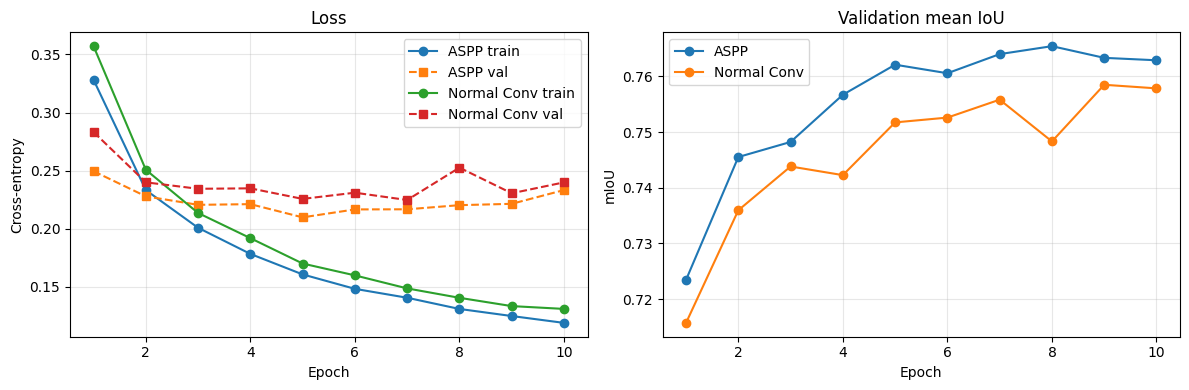

,Model,Validation Loss,Mean IoU
0,ResNet18 + ASPP,0.2334,0.7629
1,ResNet18 + Normal Conv,0.2400,0.7579


In [16]:
histories = {"ASPP": deeplab_history, "Normal Conv": baseline_history}
plot_history(histories)

comparison = pd.DataFrame([
    {"Model": "ResNet18 + ASPP", "Validation Loss": deeplab_history["val_loss"][-1],
     "Mean IoU": deeplab_history["val_iou"][-1]},
    {"Model": "ResNet18 + Normal Conv", "Validation Loss": baseline_history["val_loss"][-1],
     "Mean IoU": baseline_history["val_iou"][-1]},
])
comparison.style.format({"Validation Loss": "{:.4f}", "Mean IoU": "{:.4f}"})


## 12. Visualization predictions


In [17]:
@torch.no_grad()
def predict_mask(model, image):
    model.eval()
    logits = model(image.unsqueeze(0).to(DEVICE))
    return logits.argmax(dim=1).squeeze(0).cpu()


def compare_predictions(models, dataset, model_names, count=3):
    columns = 2 + len(models)
    fig, axes = plt.subplots(count, columns, figsize=(4 * columns, 3.5 * count))
    for row in range(count):
        image, target = dataset[row]
        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].set_title("Input")
        axes[row, 1].imshow(colorize_mask(target))
        axes[row, 1].set_title("Ground truth")
        for col, (model, name) in enumerate(zip(models, model_names), start=2):
            axes[row, col].imshow(colorize_mask(predict_mask(model, image)))
            axes[row, col].set_title(name)
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


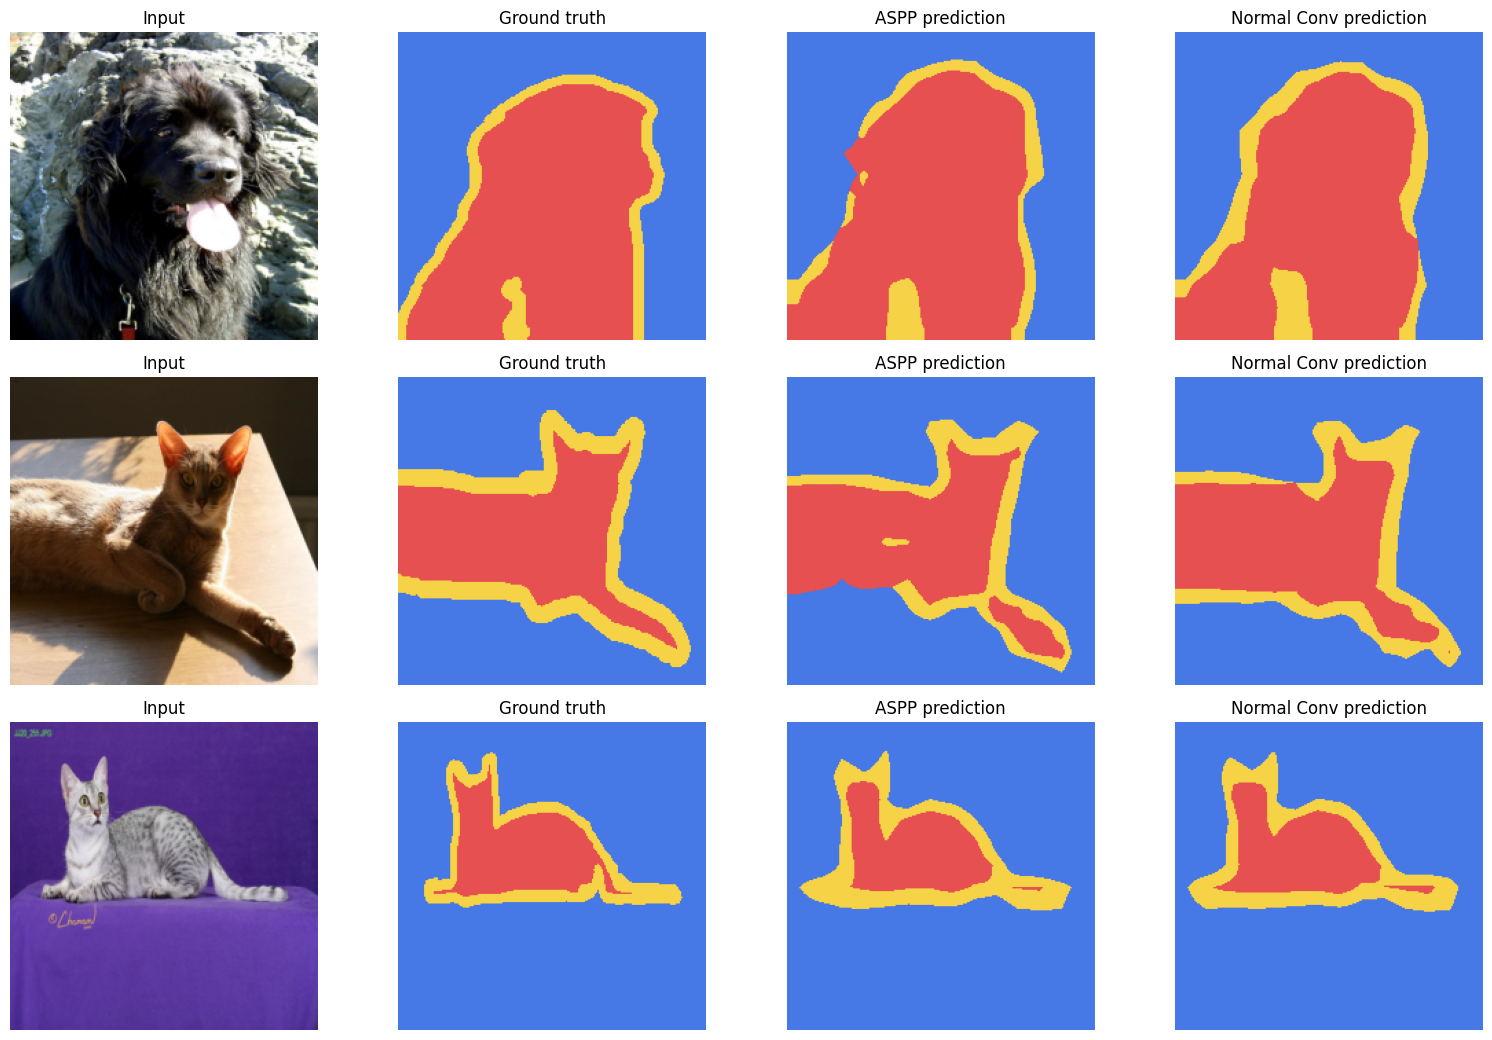

In [18]:
compare_predictions(
    [deeplab, baseline], val_dataset,
    ["ASPP prediction", "Normal Conv prediction"], count=3
)


## 13. Câu hỏi & kết luận

1. Atrous Convolution khác convolution thông thường ở điểm nào?
2. Khi tăng dilation rate, receptive field thay đổi như thế nào?
3. Vì sao ASPP sử dụng nhiều dilation rate song song?
4. Kết quả giữa ASPP và normal convolution head có khác biệt như thế nào?
5. Từ kết quả trên, hãy nhận xét vai trò của ASPP trong việc khai thác thông tin đa tỉ lệ.

**Trả lời của bạn:**

...
